# (Parametric) Linear Discriminative Classification with Hard-Margin Support Vector Machines (SVM)

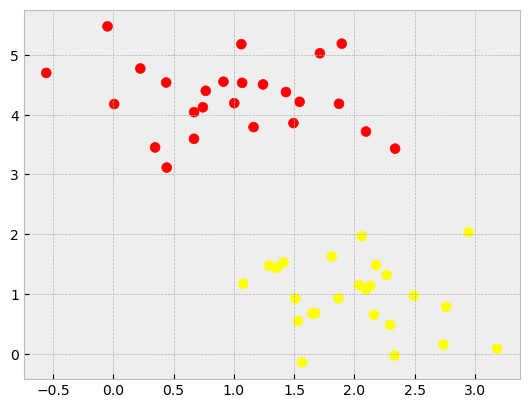

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

from sklearn.datasets import make_blobs

X, t = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn');

A linear discriminative classifier would attempt to draw a straight line separating the two sets of data, and thereby create a model for classification. For two dimensional data like that shown here, this is a task we could do by hand. But immediately we see a problem: there is more than one possible dividing line that can perfectly discriminate between the two classes!

We can draw them as follows:

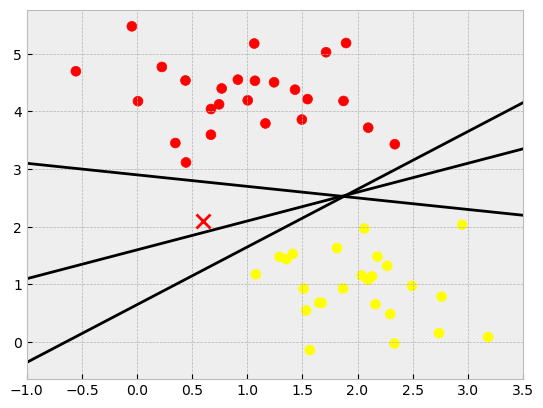

In [2]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

These are three very different separators which, nevertheless, perfectly discriminate between these samples. Depending on which you choose, a new data point (e.g., the one marked by the "X" in this plot) will be assigned a different label! Evidently our simple intuition of "drawing a line between classes" is not enough, and we need to think a bit deeper.

# Kernel Machine

Consider the following data set:

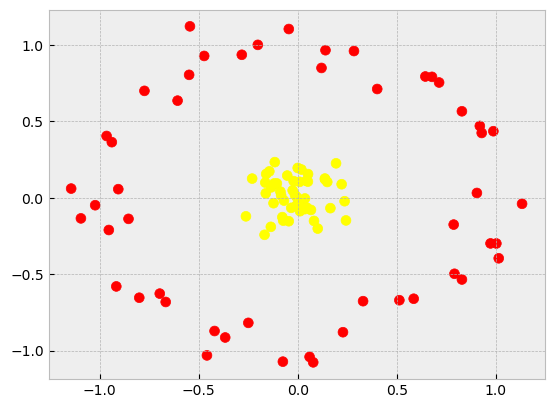

In [3]:
from sklearn.datasets import make_circles

X, t = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn');

The two classes are clearly not linearly separable. What would you do?

In [4]:
r = np.exp(-((X - X.mean(axis=0))** 2/(2*X.std(axis=0, ddof=1)**2)).sum(axis=1))

<IPython.core.display.Javascript object>


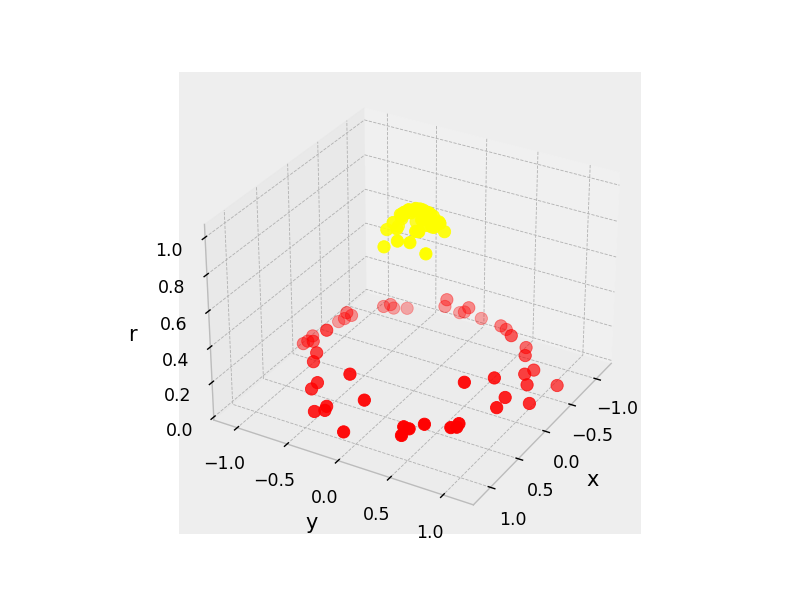

In [5]:
from mpl_toolkits import mplot3d

def plot_3D(elev=30, azim=30, X=X, y=t):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=t, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

%matplotlib notebook
plot_3D();

## Kernel Function

The kernel function is defined as:

\begin{align*}
k: \mathbb{R}^d \times \mathbb{R}^d &\longrightarrow \mathbb{R}\\
(\mathbf{x},\mathbf{y})&\longmapsto k(\mathbf{x},\mathbf{y})=\phi(\mathbf{x})^T\phi(\mathbf{y})
\end{align*}

where $\phi(x)$ is a fixed nonlinear feature space mapping

\begin{align*}
\phi: \mathbb{R}^d &\longrightarrow \mathbb{R^D}\\
\mathbf{x}&\longmapsto \phi(\mathbf{x})
\end{align*}

where $D>d$.

A popular kernel function is the **radial basis function** (RBF kernel):

\begin{align*}
k_{\text{RBF}}(\mathbf{x},\mathbf{y}) &= \exp\left(-\gamma\Vert\mathbf{x}-\mathbf{y}\Vert^2\right)
\end{align*}

typical values for $\gamma=\frac{1}{2\sigma^2}$. As you can see, the RBF kernel is measures the **similarity** between two points as a function of the kernnel *bandwidth* $\sigma$.

In [17]:
%matplotlib inline

x = np.random.rand(10)

plt.scatter(x, np.zeros(len(x)));

ValueError: s must be a scalar, or float array-like with the same size as x and y

In [15]:
x1 = np.min(x)

plt.scatter(x, np.zeros(len(x)))
plt.scatter(x1, 0, c='r');

ValueError: s must be a scalar, or float array-like with the same size as x and y

In [ ]:
sig = 0.05
xline = np.linspace(-0.2,1,100)

for i in range(len(x)):
    plt.figure(figsize=(8,5))
    plt.scatter(x, np.zeros(len(x)))
    plt.scatter(x[i], 0, c='g', marker='^')
    plt.scatter(x1, 0, c='r',marker='x')
    plt.plot(xline, np.exp(-(xline-x[i])**2/(2*sig**2))/np.sqrt(2*np.pi*sig**2))
    k_similarity=np.exp(-np.linalg.norm(x[i]-x1)**2/(2*sig**2))
    plt.title('Kernel Similarity = '+str(k_similarity));

---

# Support Vector Machines: Maximizing the Margin

SVMs offer one way to improve on this. The intuition is this: rather than simply drawing a zero-width line between the classes, we can draw around each line a margin of some width, up to the nearest point. Here is an example of how this might look:

In [ ]:
X, t = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

In support vector machines, the line that maximizes this margin is the one we will choose as the optimal model. Support vector machines are an example of such a maximum margin estimator.

# Support Vector Machine: Separable Classes

Let's start with the two-class linearly separable task and then we will extend the method to more general cases where data are not separable. Let $\phi(x_i)$, $i=1,2,\dots,N$, be the feature vectors of the training set, $X$, and corresponding target values $t_1, t_2, \cdots, t_N$ where $t_n\in\{-1,1\}$. These belong to either of two classes, $C_1$, $C_2$, which are *assumed to be linearly separable*.

The goal, once more, is to design a hyperplane

$$y(x) = w^T\phi(x) + b = 0$$

that classifies correctly all the training vectors.

Because the training data is linearly separable in the feature space, by definition there exists at least one choice of the parameters $w$ and $b$ such that $y(x)$ satisfies $y(x_n)>0$ for points having $t_n = +1$ and $y(x_n)<0$ for points having $t_n = -1$, so that $t_ny(x_n) > 0$ for all training data points.

Such a hyperplane is not unique. The perceptron algorithm may converge to any one of the possible solutions. Having gained in experience, this time we will be more demanding. 

* Which hyperplane would any sensible engineer choose as the classifier for operation in practice, where data outside the training set will be fed to it? 

* Once again, the hyperplane that leaves more “room” on either side, so that data in both classes can move a bit more freely, with less risk of causing an error. 

* A sensible choice for the hyperplane classifier would be the one that leaves the maximum margin from both classes.

* Thus such a hyperplane can be trusted more, when it is faced with the challenge of operating with unknown data.
    * It has a higher generalizarion performance.

## Quantifying the "Margin"

Let us now quantify the term "margin" that a hyperplane leaves from both classes. Every hyperplane is characterized by its direction (determined by $w$) and its exact position in space (determined by $b$). Since we want to give no preference to either of the classes, then it is reasonable for each direction to select that hyperplane which has the same distance from the respective nearest points in $c_1$ and $c_2$.

In [ ]:
from IPython.display import Image
Image('figures/Figure7.1a.png', width=400)
#Source: Bishop, Pattern Recognition and Machine Learning, 2006

In [ ]:
Image('figures/Figure7.1b.png', width=400)
#Source: Bishop, Pattern Recognition and Machine Learning, 2006

Recall that the perpendicular distance of a point $x$ from a hyperplane defined by $y(x) = 0$ where $y(x)$ takes the form $y(x) = w^T\phi(x)+b$ is given by $\frac{|y(x)|}{\Vert w\Vert}$.


Furthermore, we are only interested in solutions for which all data points are correctly classified, so that $t_n y(x_n) > 0, \forall n$. Thus the distance of a point $x_n$ to the decision surface is given by

$$\frac{t_n y(x_n)}{\Vert w\Vert} = \frac{t_n \left(w^t\phi(x_n) + b\right)}{\Vert w\Vert}$$

The margin is given by the perpendicular distance to the closest point $x_n$ from the data set, and we wish to optimize the parameters $w$ and $b$ in order to maximize this distance. Thus the maximum margin solution is found by solving

$$\arg_{w,b}\max \left\{\frac{1}{\Vert w\Vert}\min_n \left[t_n(w^T\phi(x_n)+b)\right]\right\}$$

where the factor $\frac{1}{\Vert w\Vert}$ is taken outside the optimization over $n$ because $w$ does not depend on $n$.

* Direct solution of this optimization problem would be very complex, and so we shall convert it into an equivalent problem that is much easier to solve. 

* To do this we note that if we make the rescaling $w\rightarrow \kappa w$ and $b\rightarrow \kappa b$, then the distance from any point $x_n$ to the decision surface, given by $\frac{t_n y(x_n)}{\Vert w\Vert}$, is unchanged. We can use this freedom to set

$$t_n(w^T\phi(x_n)+b) = 1$$

for the point that is closest to the surface, called the **support vectors**. In this case, all data points will satisfy the constraints

$$t_n(w^T\phi(x_n)+b) \geq 1, n=1, 2, \dots, N$$

* This is known as the canonical representation of the decision hyperplane. 

* In the case of data points for which the equality holds (support vectors), the constraints are said to be active, whereas for the remainder they are said to be inactive. 

* By definition, there will always be at least one active constraint, because there will always be a closest point, and once the margin has been maximized there will be at least two active constraints.

The optimization problem then simply requires that we maximize $\Vert w\Vert^{-1}$, which is equivalent to minimizing $\Vert w\Vert^2$, and so we have to solve the optimization problem

\begin{align*}
&\arg_{w,b}\min \frac{1}{2} \Vert w\Vert^2 \\
& \text{subject to } t_n(w^T\phi(x_n)+b) \geq 1
\end{align*}

This takes the form of a **quadratic programming** problem in which we optimize a quadratic function of a subject to a set of inequality constraints.

* The solution to a quadratic programming problem in $M$ variables in general has computational complexity that is $O(M^3)$. In going to the dual formulation we have turned the original optimization problem into the dual problem, which has $N$ variables. 
    * For a fixed set of basis functions whose number $M$ is smaller than the number $N$ of data points, the move to the dual problem appears disadvantageous. However, it allows the model to be reformulated using kernels, and so the maximum margin classifier can be applied efficiently to feature spaces whose dimensionality exceeds the number of data points, including infinite feature spaces.

---

In [ ]:
X, t = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn');

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"

SVC?

In [ ]:
svm = SVC(kernel='rbf', C=1E6)
svm.fit(X, t)

In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
plot_svc_decision_function(svm);

In [ ]:
svm.support_vectors_

In [ ]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 30, 60, 100, 200, 1000], ax=fixed(None));

In [ ]:
from sklearn.datasets import make_circles
X, t = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn');

In [ ]:
# SVM with Linear Kernel

svm = SVC(kernel='linear')
svm.fit(X, t)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
plot_svc_decision_function(svm, plot_support=False);

In [ ]:
# SVM with RBF kernel

svm = SVC(kernel='rbf', C=1E6)
svm.fit(X, t)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
plot_svc_decision_function(svm)
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

# Soft-Margin Support Vector Machines: Overlapping Classes

To handle this case, the SVM implementation has a bit of a fudge-factor which "softens" the margin: that is, it allows some of the points to creep into the margin if that allows a better fit. The hardness of the margin is controlled by a tuning parameter, most often known as **slack varible** $\xi_n \geq 0$, $n=1,\dots, N$, with one slack variable for each training data point. For very large $\xi$, the margin is hard, and points cannot lie in it. For smaller $\xi$, the margin is softer, and can grow to encompass some points.

A **slack variable** is defined as $\xi_n = 0$ for data points that are on or inside the correct margin boundary and $\xi_n = |t_n - y(x_n)|$ for other points. Thus a data point that is on the decision boundary $y(x_n) = 0$ will have $\xi_n = 1$, and points with $\xi_n > 1$ will be misclassified. The exact classification constraints are then replaced with

$$t_n y(x_n) \geq 1 - \xi_n, n = 1, \dots, N$$

in which the slack variables are constrained to satisfy $\xi_n \geq 0$. 

* Data points for which $\xi_n = 0$ are correctly classified and are either on the margin or on the correct side of the margin. 
* Points for which $0 < \xi_n \leq 1$ lie inside the margin, but on the correct side of the decision boundary.
* And those data points for which $\xi_n > 1$ lie on the wrong side of the decision boundary and are misclassified.


In [ ]:
from IPython.display import Image
Image('figures/Figure7.3.png', width=400)

Our goal is now to maximize the margin while softly penalizing points that lie on the wrong side of the margin boundary. We therefore minimize:

\begin{align*}
&\arg_{w,b} \min C\sum_{n=1}^N \xi_n + \frac{1}{2} \Vert w\Vert^2 \\
\text{subject to    } &t_n y(x_n) \geq 1 - \xi_n, n = 1, \dots, N\\
\text{and    } &\xi_n \geq 0, n = 1, \dots, N
\end{align*}

where the parameter $C>0$ controls the trade-off between the slack variable penalty and the margin.

* Because any point that is misclassified has $\xi_n >1$, it follows that $\sum_n \xi_n$ is an upper bound on the number of misclassified points. 
* The parameter $C$ is therefore analogous to (the inverse of) a regularization coefficient because it controls the trade-off between minimizing training errors and controlling model complexity.
* In the limit $C \rightarrow \infty$, we will recover the earlier support vector machine for separable data.

This also takes a form of a **quadratic programming** problem.

Although predictions for new inputs are made using only the support vectors, the training phase makes use of the whole data set, and so it is important to have **efficient algorithms for solving the quadratic programming problem**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [ ]:
from sklearn.datasets import make_blobs
X, t = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1)
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn');

In [ ]:
from sklearn.svm import SVC

In [ ]:
# Helper function
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10, 5, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, t)
    axi.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

The optimal value for the $C$ parameter will depend on your dataset, and should be tuned using cross-validation or a similar procedure.

---

# Example: Face Recognition

As an example of support vector machines in action, let's take a look at the facial recognition problem. We will use the Labeled Faces in the Wild dataset, which consists of several thousand collated photos of various public figures. A fetcher for the dataset is built into Scikit-Learn:

In [ ]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=60)

print(faces.target_names)
print(faces.images.shape)

Let's plot a few of these faces to see what we're working with:

In [ ]:
fig, ax = plt.subplots(3, 5, figsize=(8,8))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

In [ ]:
X = faces.data
t = faces.target

X.shape, t.shape

Each image contains $62\times 47$ or 2,914 pixels. We could proceed by simply using each pixel value as a feature, but often it is more effective to use some sort of pre-processor to extract more meaningful features; here we will use a PCA to extract 150 fundamental components to feed into our support vector machine classifier. We can do this most straightforwardly by packaging the preprocessor and the classifier into a single pipeline:

In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

pipe = Pipeline(steps=[('STD', MinMaxScaler()),
                      ('PCA', PCA(n_components=150)),
                      ('SVM', SVC(kernel='rbf', class_weight='balanced'))])

pipe

For the sake of testing our classifier output, we will split the data into a training and testing set:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    stratify=t,
                                                    test_size=0.2,
                                                    random_state=0)

X_train.shape, X_test.shape, t_train.shape, t_test.shape

Finally, we can use a grid search cross-validation to explore combinations of parameters. Here we will adjust ```C``` (which controls the margin hardness) and ```gamma``` (which controls the size of the radial basis function kernel), and determine the best model:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = dict(SVM__C=[1, 5, 10, 50],
                  SVM__gamma=[0.0001, 0.0005, 0.001, 0.005])

grid = GridSearchCV(pipe, param_grid, refit=True)

grid.fit(X_train, t_train)

print(grid.best_params_)

In [ ]:
final_model = grid.best_estimator_

In [ ]:
from scipy import stats
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_model, X_train, t_train,
                        scoring='accuracy',
                        cv=5)

confidence = 0.95
stats.t.interval(confidence,
                 len(scores)-1,
                 loc = scores.mean(),
                 scale=scores.std(ddof=1)/np.sqrt(len(scores)))

The optimal values fall toward the middle of our grid; if they fell at the edges, we would want to expand the grid to make sure we have found the true optimum.

Now with this cross-validated model, we can predict the labels for the test data, which the model has not yet seen:

In [ ]:
y_train = final_model.predict(X_train)
y_test = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Accuracy in Training:', accuracy_score(t_train, y_train)*100,'%\n')
print('Accuracy in Test:', accuracy_score(t_test, y_test)*100,'%')

Let's take a look at a few of the test images along with their predicted values:

In [ ]:
fig, ax = plt.subplots(4, 6, figsize=(8,8))
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_xlabel(faces.target_names[y_test[i]].split()[-1],
                   color='black' if y_test[i] == t_test[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

Out of this small sample, our optimal estimator mislabeled only a single face (Bush’s face in the bottom row was mislabeled as Blair). We can get a better sense of our estimator's performance using the classification report, which lists summary statistics label by label:

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(t_train, y_train, target_names=faces.target_names))

In [ ]:
print(classification_report(t_test, y_test, target_names=faces.target_names))

We might also display the confusion matrix between these classes:

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(t_test, y_test)

disp = ConfusionMatrixDisplay(cm, display_labels=faces.target_names)
disp.plot(xticks_rotation='vertical');

This helps us get a sense of which labels are likely to be confused by the classifier.

For a real-world facial recognition task, in which the photos do not come pre-cropped into nice grids, the only difference in the facial classification scheme is the feature selection: you would need to use a more sophisticated algorithm to find the faces, and extract features that are independent of the pixellation. 

* For this kind of application, one good option is to make use of [OpenCV](https://opencv.org/), which, among other things, includes pre-trained implementations of state-of-the-art feature extraction tools for images in general and faces in particular.

## Support Vector Machine Summary

We have seen here a brief intuitive introduction to the principals behind support vector machines. These methods are a powerful classification method for a number of reasons:

Their dependence on relatively few support vectors means that they are very compact models, and take up very little memory.
Once the model is trained, the prediction phase is very fast.
Because they are affected only by points near the margin, they work well with high-dimensional data—even data with more dimensions than samples, which is a challenging regime for other algorithms.
Their integration with kernel methods makes them very versatile, able to adapt to many types of data.
However, SVMs have several disadvantages as well:

The scaling with the number of samples $N$ is $\mathcal{O}[N^3]$ at worst, or $\mathcal{O}[N^2]$ for efficient implementations. For large numbers of training samples, this computational cost can be prohibitive.
The results are strongly dependent on a suitable choice for the softening parameter $C$. This must be carefully chosen via cross-validation, which can be expensive as datasets grow in size.
The results do not have a direct probabilistic interpretation. This can be estimated via an internal cross-validation (see the probability parameter of SVC), but this extra estimation is costly.
With those traits in mind, I generally only turn to SVMs once other simpler, faster, and less tuning-intensive methods have been shown to be insufficient for my needs. Nevertheless, if you have the CPU cycles to commit to training and cross-validating an SVM on your data, the method can lead to excellent results.

# Comparing k-NN, Decision Trees, Random Forests, Linear SVM & RBF SVM

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification, make_blobs
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier, AdaBoostRegressor
from sklearn.metrics import r2_score

In [ ]:
# figure parameters
h = .02  # step size in the mesh
figure = plt.figure(figsize=(20, 9))

# set up classifiers
classifiers = [LogisticRegression(multi_class='multinomial'),\
               DecisionTreeClassifier(max_depth=5),\
               RandomForestClassifier(max_depth=5, n_estimators=100, max_features=1),\
               AdaBoostClassifier(RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
                                  n_estimators=100, learning_rate=1,random_state=0),\
               SVC(kernel="linear", C=0.025),\
               SVC(gamma=2, C=1)
              ]

names = ["Logistic Regression","Decision Tree", "Random Forest", "AdaBoost", "Linear SVM", "RBF SVM"]


# Put together Data Sets
n_samples = 300
X, y = make_classification(n_samples=n_samples, n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 1*rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [make_moons(noise=0.3, random_state=0,n_samples=n_samples),
            make_circles(noise=0.2, factor=0.5, random_state=1,n_samples=n_samples),
            linearly_separable,
            make_blobs(random_state=1,cluster_std=[3.0,4.0,2.5],n_samples=n_samples)
            ]

i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.3, random_state=42)

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = ListedColormap(['cornflowerblue','yellowgreen','orange']) #plt.cm.RdBu
    cm_bright = ListedColormap(['blue','olivedrab','chocolate'])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
               edgecolors='k',label='Training points')
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=y_test, cmap=cm_bright, alpha=0.6,
               edgecolors='k',label='Test points')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    ax.legend()
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
#         Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
                   edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=y_test, cmap=cm_bright,
                   edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
                size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()

In [ ]:
# figure parameters
h = .02  # step size in the mesh
figure = plt.figure(figsize=(20, 9))

# set up regressors
regressors = [LinearRegression(),
               DecisionTreeRegressor(max_depth=5),
               RandomForestRegressor(max_depth=5, n_estimators=100, max_features=1),
               AdaBoostRegressor(RandomForestRegressor(max_depth=5, n_estimators=10, max_features=1),
                                  n_estimators=100, learning_rate=1,random_state=0),
               SVR(kernel="linear", C=0.025),
               SVR(gamma=2, C=100)]

# names = ["Linear Regression","Decision Tree", "Random Forest", "AdaBoost", "Linear SVM", "RBF SVM"]
names = ['A', 'B', 'C', 'D', 'E', 'F']

# Put together Data Sets
n_samples = 300
X = np.linspace(0,2,n_samples)
t = np.sin(2*np.pi*X) + np.random.normal(0,0.5,n_samples)
noisy_sine_curve = (X.reshape(-1,1), t)

rng = np.random.RandomState(42)
X = 10 * rng.rand(n_samples)
sigma=0.3
t = np.sin(5 * X) + np.sin(0.5 * X) + sigma * rng.randn(len(X))
fast_and_slow_oscillation = (X.reshape(-1,1),t)

X = np.linspace(0,10,n_samples)
t = 3*(X-5)**2 + 6* np.random.randn(n_samples)
noisy_quadratic=(X.reshape(-1,1),t)

datasets = [noisy_sine_curve, fast_and_slow_oscillation, noisy_quadratic]

i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, t = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                        test_size=.3, 
                                                        random_state=42)
    
    # Synthetic data for plotting
    xx = np.linspace(-1.7,1.7,100).reshape(-1,1)
    
    ax = plt.subplot(len(datasets), len(regressors) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    plt.scatter(X_train, t_train, c='blue', alpha=0.5, edgecolors='k',label='Training points')
    # Plot the testing points
    plt.scatter(X_test, t_test, c='red', alpha=0.5, marker='^', edgecolors='k',label='Test points')
    plt.legend()
    i += 1

    # iterate over regressors
    for name, reg in zip(names, regressors):
        ax = plt.subplot(len(datasets), len(regressors) + 1, i)
        
        # Training regressor
        reg.fit(X_train, t_train)
        
        # Making predictions
        y_train = reg.predict(X_train)
        y_test = reg.predict(X_test)
        
        # r2-score in test
        score = r2_score(t_test, y_test)

        # Plot the predictions
        ax.plot(xx, reg.predict(xx), 'cyan')
        ax.scatter(X_train, t_train, c='blue', alpha=0.5, edgecolors='k',label='Training points')
        # Plot the testing points
        ax.scatter(X_test, t_test, c='red', alpha=0.5, marker='^', edgecolors='k',label='Test points')
        
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(xx.max() - 2.5, yy.min() + 0.5, ('%.2f' % score).lstrip('0'),
                size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()

---